# **Lab 05.2 - Continuous and Policy-Based RL with DDPG and PPO**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
  
This lab contains the following practical parts:
1. Part 1,2 — Build and validate the EdgeOffloadingEnv (device vs. edge).
2. Part 3 — Implement baseline policies (random, device-only, edge-only, greedy).
3. Part 4 — A2C
4. Part 5 — PPO
6. Part 6 — Final comparison and analysis of all methods.


In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

# import os
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# os.environ['OMP_NUM_THREADS'] = '1'
# os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_return': float(np.mean(episode_rewards)),
        'std_return': float(np.std(episode_rewards)),
        'max_return': float(np.max(episode_rewards)),
        'min_return': float(np.min(episode_rewards)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cuda
PyTorch: 2.5.1+cu121
NumPy: 2.2.6
Gymnasium: 1.2.3
FAST_MODE: True


In [2]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    OBS_LOW = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
    OBS_HIGH = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        self.f_device = 1.0  # GHz
        self.f_edge = 5.0    # GHz
        self.max_steps = int(max_steps)
        self.step_count = 0
        self.state = None

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(
            low=self.OBS_LOW,
            high=self.OBS_HIGH,
            shape=(4,),
            dtype=np.float32,
        )

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        return self.np_random.uniform(self.OBS_LOW, self.OBS_HIGH).astype(np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        input_size, workload, uplink_rate, edge_queue = np.asarray(state, dtype=np.float32)

        latency_device = (workload / self.f_device) * 1000.0
        upload_latency = (input_size / uplink_rate) * 1000.0
        latency_edge = upload_latency + edge_queue + (workload / self.f_edge) * 1000.0

        return float(latency_device), float(latency_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        super().reset(seed=seed)
        if seed is not None:
            self.action_space.seed(seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        if self.state is None:
            raise RuntimeError('Call reset() before step().')
        if not self.action_space.contains(action):
            raise ValueError(f'Invalid action {action}. Expected 0=device or 1=edge.')

        action = int(action)
        latency_device, latency_edge = self._compute_latencies(self.state)
        selected_latency = latency_device if action == 0 else latency_edge
        reward = -selected_latency / 1000.0

        self.step_count += 1
        terminated = False
        truncated = self.step_count >= self.max_steps

        info = {
            'latency': float(selected_latency),
            'latency_device': float(latency_device),
            'latency_edge': float(latency_edge),
            'action': action,
            'action_name': 'device' if action == 0 else 'edge',
        }

        self.state = self._sample_state()
        return self.state.copy(), float(reward), terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [3]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=0, reward=-1.372747, latency=1372.75ms, action_name=device
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=1, reward=-0.862474, latency=862.47ms, action_name=edge
Step 4: action=0, reward=-2.486009, latency=2486.01ms, action_name=device
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [4]:
# ============================================================================
# Baseline policy functions
# ============================================================================

def make_edge_env(seed=None, max_steps=50):
    """Factory used by training and evaluation code."""
    env = EdgeOffloadingEnv(max_steps=max_steps)
    if seed is not None:
        env.reset(seed=seed)
    return env


def random_edge_policy(state, env=None):
    """Choose device/edge uniformly at random."""
    if env is not None:
        return env.action_space.sample()
    return int(np.random.randint(2))


def device_only_policy(state, env=None):
    """Always execute on the mobile device."""
    return 0


def edge_only_policy(state, env=None):
    """Always offload to the edge server."""
    return 1


def greedy_latency_policy(state, env):
    """Choose the action with lower immediate latency."""
    latency_device, latency_edge = env._compute_latencies(state)
    return int(latency_edge < latency_device)


baseline_policies = {
    'Random': random_edge_policy,
    'Device-only': device_only_policy,
    'Edge-only': edge_only_policy,
    'Greedy latency': greedy_latency_policy,
}

print('Baseline policies:', ', '.join(baseline_policies.keys()))

Baseline policies: Random, Device-only, Edge-only, Greedy latency


,Policy,Avg Latency (ms),P95 Latency (ms),Avg Return,Std Return,Max Return,Device %,Edge %
0,Greedy latency,1133.713013,2344.842285,-56.685646,4.781634,-46.163922,49.2,50.8
1,Device-only,1535.334473,2855.375000,-76.766723,6.687031,-62.273619,100.0,0.0
2,Random,1641.543213,3196.879639,-82.077158,9.451480,-65.009666,49.4,50.6
3,Edge-only,1738.728027,4301.544434,-86.936404,10.680115,-62.316708,0.0,100.0


,Optimal Edge %,Device-only Avg Latency,Edge-only Avg Latency,Greedy Avg Latency,Edge Better Avg Margin,Device Better Avg Margin
0,51.702,1552.281128,1749.318237,1134.98584,807.115906,1271.962402


If Optimal Edge % is far from 0%, a learned only-device policy is a training collapse, not a property of the environment.


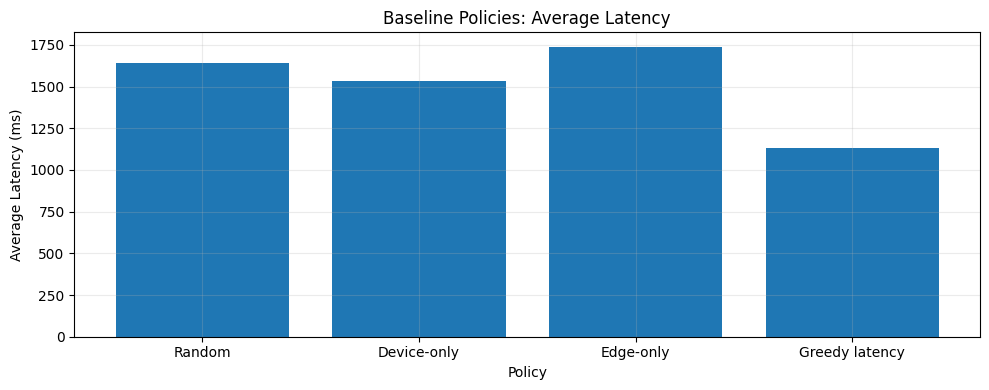

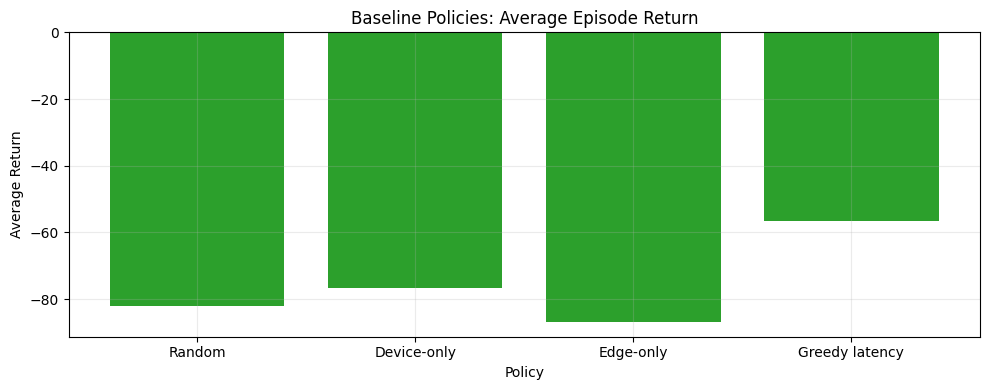

In [5]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

baseline_eval_episodes = 30 if FAST_MODE else 100
baseline_results = {}

for policy_name, policy_fn in baseline_policies.items():
    result = evaluate_edge_policy(make_edge_env, policy_fn, episodes=baseline_eval_episodes)
    baseline_results[policy_name] = result

baseline_df = pd.DataFrame([
    {
        'Policy': name,
        'Avg Latency (ms)': result['avg_latency'],
        'P95 Latency (ms)': result['p95_latency'],
        'Avg Return': result['avg_return'],
        'Std Return': result['std_return'],
        'Max Return': result['max_return'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    }
    for name, result in baseline_results.items()
])

display(baseline_df.sort_values('Avg Latency (ms)').reset_index(drop=True))

def diagnose_action_landscape(sample_count=50000):
    """Check whether the environment itself is biased toward one action."""
    rng = np.random.default_rng(SEED + 123)
    states = rng.uniform(
        EdgeOffloadingEnv.OBS_LOW,
        EdgeOffloadingEnv.OBS_HIGH,
        size=(sample_count, 4),
    ).astype(np.float32)
    input_size, workload, uplink_rate, edge_queue = states.T
    latency_device = workload * 1000.0
    latency_edge = input_size / uplink_rate * 1000.0 + edge_queue + workload / 5.0 * 1000.0
    greedy_edge = latency_edge < latency_device

    return pd.DataFrame([{
        'Optimal Edge %': float(greedy_edge.mean() * 100.0),
        'Device-only Avg Latency': float(latency_device.mean()),
        'Edge-only Avg Latency': float(latency_edge.mean()),
        'Greedy Avg Latency': float(np.minimum(latency_device, latency_edge).mean()),
        'Edge Better Avg Margin': float((latency_device - latency_edge)[greedy_edge].mean()),
        'Device Better Avg Margin': float((latency_edge - latency_device)[~greedy_edge].mean()),
    }])


landscape_df = diagnose_action_landscape()
display(landscape_df)
print(
    'If Optimal Edge % is far from 0%, a learned only-device policy is a training collapse, '
    'not a property of the environment.'
)

plt.figure(figsize=(10, 4))
plt.bar(baseline_df['Policy'], baseline_df['Avg Latency (ms)'])
plt.title('Baseline Policies: Average Latency')
plt.xlabel('Policy')
plt.ylabel('Average Latency (ms)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(baseline_df['Policy'], baseline_df['Avg Return'], color='tab:green')
plt.title('Baseline Policies: Average Episode Return')
plt.xlabel('Policy')
plt.ylabel('Average Return')
plt.tight_layout()
plt.show()

---

# PART 4: A2C 


### 4.1 A2C Training and Evaluation



PART 4: A2C  ON EDGE OFFLOADING ENV
 A2C ep 50 | t=2500/20000 | return=-75.776 | avg latency=1515.53 ms
 A2C ep 100 | t=5000/20000 | return=-71.357 | avg latency=1427.14 ms
 A2C ep 150 | t=7500/20000 | return=-55.674 | avg latency=1113.47 ms
 A2C ep 200 | t=10000/20000 | return=-61.809 | avg latency=1236.18 ms
 A2C ep 250 | t=12500/20000 | return=-52.331 | avg latency=1046.62 ms
 A2C ep 300 | t=15000/20000 | return=-60.697 | avg latency=1213.95 ms
 A2C ep 350 | t=17500/20000 | return=-59.488 | avg latency=1189.75 ms
 A2C ep 400 | t=20000/20000 | return=-58.194 | avg latency=1163.88 ms


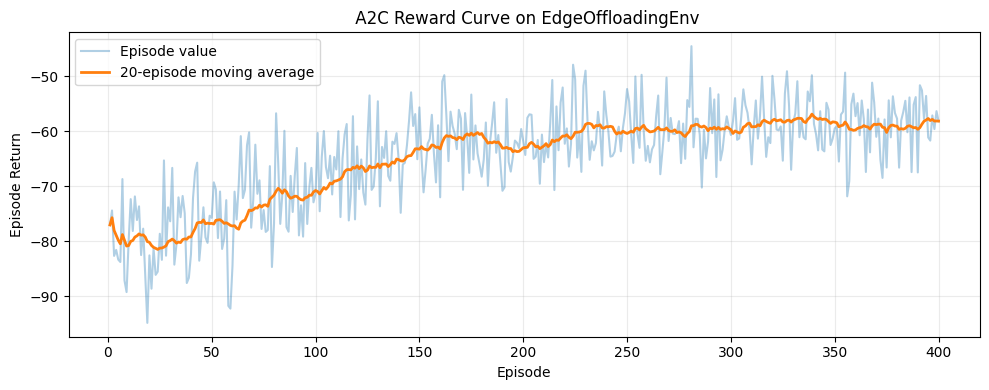

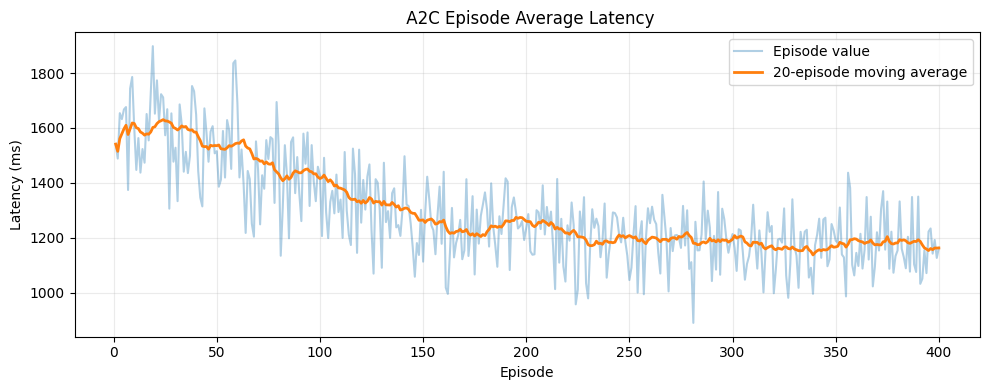

 A2C avg latency: 1150.69 ms
 A2C p95 latency: 2390.55 ms
 A2C avg return: -57.535
 A2C std return: 4.927
 A2C max return: -46.697
 A2C actions: device=45.8%, edge=54.2%


,Method,Deterministic Edge %,Mean P(edge),Greedy Agreement %,Greedy Edge %
0,A2C,55.48,55.216606,92.44,51.88


,Method,Episodes,Avg Return,Std Return,Max Return,Final Window Avg,Final Window Std
0,A2C,400,-64.47451,9.098174,-44.53051,-58.168549,4.664693


In [ ]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================

print("\n" + "="*60)
print("PART 4: A2C  ON EDGE OFFLOADING ENV")
print("="*60)

edge_obs_low_t = torch.as_tensor(EdgeOffloadingEnv.OBS_LOW, dtype=torch.float32, device=device)
edge_obs_scale_t = torch.as_tensor(
    EdgeOffloadingEnv.OBS_HIGH - EdgeOffloadingEnv.OBS_LOW,
    dtype=torch.float32,
    device=device,
)


def edge_state_to_tensor(state):
    """Normalize one EdgeOffloadingEnv state and add a batch dimension."""
    state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
    return ((state_t - edge_obs_low_t) / edge_obs_scale_t).unsqueeze(0)


def summarize_training_returns(method_name, returns, window=20):
    """Summarize training stability from an episode-return curve."""
    returns = np.asarray(returns, dtype=np.float32)
    if len(returns) == 0:
        return {
            'Method': method_name,
            'Episodes': 0,
            'Avg Return': np.nan,
            'Std Return': np.nan,
            'Max Return': np.nan,
            'Final Window Avg': np.nan,
            'Final Window Std': np.nan,
        }
    recent = returns[-min(window, len(returns)):]
    return {
        'Method': method_name,
        'Episodes': int(len(returns)),
        'Avg Return': float(np.mean(returns)),
        'Std Return': float(np.std(returns)),
        'Max Return': float(np.max(returns)),
        'Final Window Avg': float(np.mean(recent)),
        'Final Window Std': float(np.std(recent)),
    }


def diagnose_learned_policy(model, method_name, sample_count=5000):
    """Compare a learned deterministic policy with the greedy latency oracle."""
    rng = np.random.default_rng(SEED + 900)
    states = rng.uniform(
        EdgeOffloadingEnv.OBS_LOW,
        EdgeOffloadingEnv.OBS_HIGH,
        size=(sample_count, 4),
    ).astype(np.float32)
    input_size, workload, uplink_rate, edge_queue = states.T
    latency_device = workload * 1000.0
    latency_edge = input_size / uplink_rate * 1000.0 + edge_queue + workload / 5.0 * 1000.0
    greedy_actions = (latency_edge < latency_device).astype(np.int64)

    model.eval()
    with torch.no_grad():
        state_t = (torch.as_tensor(states, dtype=torch.float32, device=device) - edge_obs_low_t) / edge_obs_scale_t
        logits, _ = model(state_t)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        learned_actions = np.argmax(probs, axis=1)

    diagnostics = {
        'Method': method_name,
        'Deterministic Edge %': float(np.mean(learned_actions == 1) * 100.0),
        'Mean P(edge)': float(np.mean(probs[:, 1]) * 100.0),
        'Greedy Agreement %': float(np.mean(learned_actions == greedy_actions) * 100.0),
        'Greedy Edge %': float(np.mean(greedy_actions == 1) * 100.0),
    }
    display(pd.DataFrame([diagnostics]))
    return diagnostics


class A2CNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_dim, output_dim)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features = self.shared(x)
        logits = self.policy_head(features)
        values = self.value_head(features).squeeze(-1)
        return logits, values


def train_a2c_edge(
    total_timesteps=20000,
    n_steps=64,
    gamma=0.0,
    gae_lambda=0.0,
    lr=3e-4,
    value_coef=0.5,
    ent_coef=0.03,
    max_grad_norm=0.5,
):
    model = A2CNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    env = make_edge_env(seed=SEED + 5000)
    state, _ = env.reset(seed=SEED + 5000)

    episode_returns, episode_avg_latencies = [], []
    current_return, current_latencies = 0.0, []
    timesteps = 0
    last_done = False

    while timesteps < total_timesteps:
        rollout_rewards, rollout_dones = [], []
        rollout_values, rollout_log_probs, rollout_entropies = [], [], []

        rollout_size = min(n_steps, total_timesteps - timesteps)
        for _ in range(rollout_size):
            state_t = edge_state_to_tensor(state)
            logits, value = model(state_t)
            dist = Categorical(logits=logits)
            action = dist.sample()

            next_state, reward, terminated, truncated, info = env.step(int(action.item()))
            done = terminated or truncated

            rollout_rewards.append(float(reward))
            rollout_dones.append(done)
            rollout_values.append(value.squeeze(0))
            rollout_log_probs.append(dist.log_prob(action).squeeze(0))
            rollout_entropies.append(dist.entropy().squeeze(0))

            current_return += float(reward)
            current_latencies.append(float(info['latency']))
            timesteps += 1
            state = next_state
            last_done = done

            if done:
                episode_returns.append(current_return)
                episode_avg_latencies.append(float(np.mean(current_latencies)))
                if len(episode_returns) % 50 == 0:
                    print(
                        f" A2C ep {len(episode_returns)} | "
                        f"t={timesteps}/{total_timesteps} | "
                        f"return={current_return:.3f} | "
                        f"avg latency={episode_avg_latencies[-1]:.2f} ms"
                    )
                state, _ = env.reset(seed=SEED + 5000 + len(episode_returns))
                current_return, current_latencies = 0.0, []

        values_t = torch.stack(rollout_values).view(-1)
        log_probs_t = torch.stack(rollout_log_probs).view(-1)
        entropies_t = torch.stack(rollout_entropies).view(-1)
        rewards_t = torch.tensor(rollout_rewards, dtype=torch.float32, device=device).view(-1)
        dones_t = torch.tensor(rollout_dones, dtype=torch.float32, device=device).view(-1)

        with torch.no_grad():
            if last_done:
                next_value = torch.tensor(0.0, dtype=torch.float32, device=device)
            else:
                _, next_value = model(edge_state_to_tensor(state))
                next_value = next_value.squeeze(0)

            advantages = torch.zeros_like(rewards_t)
            last_gae_lam = torch.tensor(0.0, dtype=torch.float32, device=device)
            for t in reversed(range(len(rollout_rewards))):
                if t == len(rollout_rewards) - 1:
                    next_non_terminal = 1.0 - dones_t[t]
                    next_values = next_value
                else:
                    next_non_terminal = 1.0 - dones_t[t]
                    next_values = values_t[t + 1]
                delta = rewards_t[t] + gamma * next_values * next_non_terminal - values_t[t]
                last_gae_lam = delta + gamma * gae_lambda * next_non_terminal * last_gae_lam
                advantages[t] = last_gae_lam
            returns_t = advantages + values_t
            normalized_advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)

        policy_loss = -(log_probs_t * normalized_advantages).mean()
        value_loss = nn.functional.mse_loss(values_t, returns_t)
        entropy_loss = -entropies_t.mean()
        loss = policy_loss + value_coef * value_loss + ent_coef * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

    env.close()
    return model, episode_returns, episode_avg_latencies


# EdgeOffloadingEnv samples the next task independently, so each decision is
# close to a contextual bandit. gamma=0 focuses learning on immediate latency
# and avoids collapse toward the globally safer average action.
A2C_TOTAL_TIMESTEPS = 20000 if FAST_MODE else 60000
A2C_MODEL, custom_a2c_train_rewards, custom_a2c_train_latencies = train_a2c_edge(
    total_timesteps=A2C_TOTAL_TIMESTEPS,
    n_steps=64,
    gamma=0.0,
    gae_lambda=0.0,
    lr=3e-4,
    ent_coef=0.03,
)

plot_curve(
    custom_a2c_train_rewards,
    title=' A2C Reward Curve on EdgeOffloadingEnv',
    ylabel='Episode Return',
    window=20,
)
plot_curve(
    custom_a2c_train_latencies,
    title=' A2C Episode Average Latency',
    ylabel='Latency (ms)',
    window=20,
)


def custom_a2c_action_fn(state, env=None):
    """Deterministic Custom A2C policy for evaluation."""
    A2C_MODEL.eval()
    with torch.no_grad():
        logits, _ = A2C_MODEL(edge_state_to_tensor(state))
        return int(torch.argmax(logits, dim=-1).item())


a2c_eval_episodes = 30 if FAST_MODE else 100
custom_a2c_result = evaluate_edge_policy(make_edge_env, custom_a2c_action_fn, episodes=a2c_eval_episodes)
a2c_available = True
a2c_result = custom_a2c_result

print(f" A2C avg latency: {custom_a2c_result['avg_latency']:.2f} ms")
print(f" A2C p95 latency: {custom_a2c_result['p95_latency']:.2f} ms")
print(f" A2C avg return: {custom_a2c_result['avg_return']:.3f}")
print(f" A2C std return: {custom_a2c_result['std_return']:.3f}")
print(f" A2C max return: {custom_a2c_result['max_return']:.3f}")
print(f" A2C actions: device={custom_a2c_result['device_pct']:.1f}%, "
      f"edge={custom_a2c_result['edge_pct']:.1f}%")
a2c_policy_diagnostics = diagnose_learned_policy(A2C_MODEL, 'A2C')

a2c_training_summary = summarize_training_returns('A2C', custom_a2c_train_rewards)
display(pd.DataFrame([a2c_training_summary]))


In [7]:
print("\n" + "="*60)
print("PART 4.2: OPTIONAL A2C (STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# Optional SB3 A2C training and evaluation
# ============================================================================

RUN_SB3_A2C = False
sb3_a2c_available = False
sb3_a2c_result = None

try:
    from stable_baselines3 import A2C as SB3A2C
except Exception as exc:
    print(f'Stable-Baselines3 A2C skipped: {exc}')
else:
    print('SB3 A2C is available. RUN_SB3_A2C is False, so the Lab 4 custom A2C result is used above.')
    if RUN_SB3_A2C:
        sb3_env = make_edge_env(seed=SEED + 7000)
        sb3_model = SB3A2C(
            'MlpPolicy',
            sb3_env,
            learning_rate=7e-4,
            n_steps=32,
            gamma=0.0,
            ent_coef=0.03,
            seed=SEED,
            verbose=0,
        )
        sb3_timesteps = 10000 if FAST_MODE else 50000
        sb3_model.learn(total_timesteps=sb3_timesteps, progress_bar=False)
        sb3_env.close()

        def sb3_a2c_action_fn(state, env=None):
            action, _ = sb3_model.predict(state, deterministic=True)
            return int(action)

        sb3_a2c_result = evaluate_edge_policy(make_edge_env, sb3_a2c_action_fn, episodes=a2c_eval_episodes)
        sb3_a2c_available = True
        print(f"SB3 A2C avg latency: {sb3_a2c_result['avg_latency']:.2f} ms")
        print(f"SB3 A2C avg return: {sb3_a2c_result['avg_return']:.3f}")


PART 4.2: OPTIONAL A2C (STABLE-BASELINES3)
SB3 A2C is available. RUN_SB3_A2C is False, so the Lab 4 custom A2C result is used above.


---

# PART 5: PPO on EdgeOffloadingEnv

**Pipeline Architecture**:
1. Feed edge state tensors into shared feature blocks.
2. Produce offloading-action logits via `ppo_scratch_policy_net`.
3. Produce scalar baseline via `ppo_scratch_value_net`.
4. Sample actions from Categorical logits for on-policy exploration.

**Component Interactions**:
- Policy and value heads share encoded system-state features.
- Outputs are consumed by rollout collection and PPO optimization below.

**Mathematical/Algorithmic Anchors**:
- Categorical stochastic policy over offloading decisions.
- Baseline value estimate for advantage reduction.



PART 5: PPO ON EDGE OFFLOADING ENV
PPO update 5 | t=2560/20000 | recent return=-74.695
PPO update 10 | t=5120/20000 | recent return=-62.345
PPO update 15 | t=7680/20000 | recent return=-58.849
PPO update 20 | t=10240/20000 | recent return=-59.505
PPO update 25 | t=12800/20000 | recent return=-55.399
PPO update 30 | t=15360/20000 | recent return=-57.796
PPO update 35 | t=17920/20000 | recent return=-59.616
PPO update 40 | t=20000/20000 | recent return=-56.531


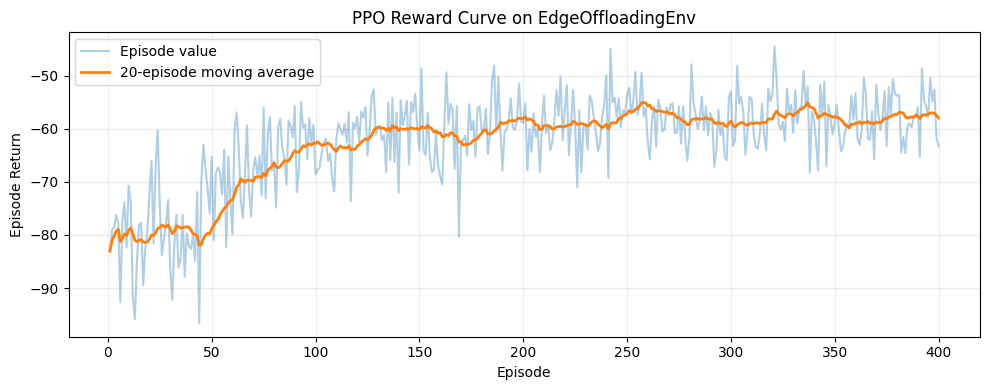

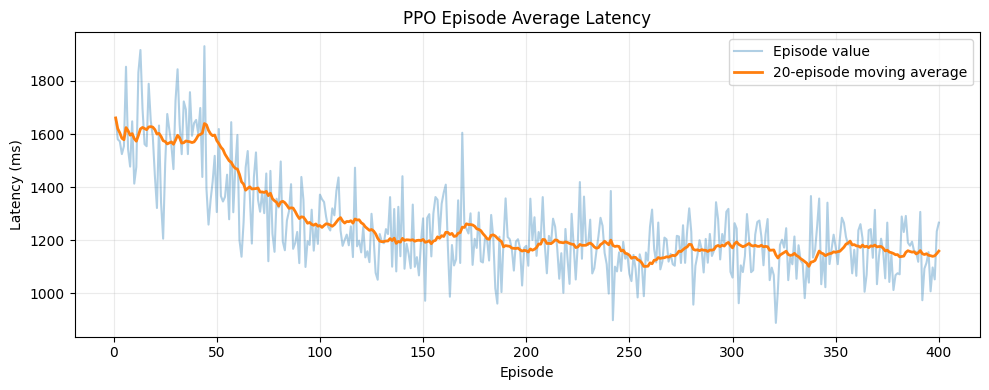

PPO avg latency: 1148.43 ms
PPO p95 latency: 2385.30 ms
PPO avg return: -57.422
PPO std return: 4.886
PPO max return: -46.293
PPO actions: device=49.7%, edge=50.3%


,Method,Deterministic Edge %,Mean P(edge),Greedy Agreement %,Greedy Edge %
0,PPO,50.78,50.860722,92.98,51.88


,Method,Episodes,Avg Return,Std Return,Max Return,Final Window Avg,Final Window Std
0,PPO,400,-62.348358,8.923788,-44.468231,-57.983612,4.595471


In [8]:
print("\n" + "="*60)
print("PART 5: PPO ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# PPO Networks
# ============================================================================

class PPOEdgeNetwork(nn.Module):
    """PPO actor-critic network for discrete offloading decisions."""

    def __init__(self, input_dim=4, hidden_dim=128, action_dim=2):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.ppo_scratch_policy_net = nn.Linear(hidden_dim, action_dim)
        self.ppo_scratch_value_net = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.ppo_scratch_policy_net(features)
        values = self.ppo_scratch_value_net(features).squeeze(-1)
        return logits, values


def train_ppo_edge(
    total_timesteps=20000,
    rollout_steps=512,
    ppo_epochs=4,
    minibatch_size=128,
    gamma=0.0,
    gae_lambda=0.0,
    clip_coef=0.2,
    lr=3e-4,
    value_coef=0.5,
    ent_coef=0.03,
    max_grad_norm=0.5,
):
    """Train PPO with clipped policy updates and GAE."""
    model = PPOEdgeNetwork(input_dim=4, hidden_dim=128, action_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    env = make_edge_env(seed=SEED + 8000)
    state, _ = env.reset(seed=SEED + 8000)

    episode_returns, episode_avg_latencies = [], []
    current_return, current_latencies = 0.0, []
    timesteps, update_idx = 0, 0
    last_done = False

    while timesteps < total_timesteps:
        states, actions, old_log_probs, rewards, dones, values = [], [], [], [], [], []
        rollout_size = min(rollout_steps, total_timesteps - timesteps)

        for _ in range(rollout_size):
            state_t = edge_state_to_tensor(state)
            with torch.no_grad():
                logits, value = model(state_t)
                dist = Categorical(logits=logits)
                action = dist.sample()
                log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, info = env.step(int(action.item()))
            done = terminated or truncated

            states.append(state_t.squeeze(0))
            actions.append(action.squeeze(0))
            old_log_probs.append(log_prob.squeeze(0))
            rewards.append(float(reward))
            dones.append(done)
            values.append(value.squeeze(0))

            current_return += float(reward)
            current_latencies.append(float(info['latency']))
            timesteps += 1
            state = next_state
            last_done = done

            if done:
                episode_returns.append(current_return)
                episode_avg_latencies.append(float(np.mean(current_latencies)))
                state, _ = env.reset(seed=SEED + 8000 + len(episode_returns))
                current_return, current_latencies = 0.0, []

        states_t = torch.stack(states)
        actions_t = torch.stack(actions).long().view(-1)
        old_log_probs_t = torch.stack(old_log_probs).view(-1)
        values_t = torch.stack(values).view(-1)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device).view(-1)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=device).view(-1)

        with torch.no_grad():
            if last_done:
                next_value = torch.tensor(0.0, dtype=torch.float32, device=device)
            else:
                _, next_value = model(edge_state_to_tensor(state))
                next_value = next_value.squeeze(0)

            advantages = torch.zeros_like(rewards_t)
            last_gae_lam = torch.tensor(0.0, dtype=torch.float32, device=device)
            for t in reversed(range(rollout_size)):
                if t == rollout_size - 1:
                    next_non_terminal = 1.0 - dones_t[t]
                    next_values = next_value
                else:
                    next_non_terminal = 1.0 - dones_t[t]
                    next_values = values_t[t + 1]
                delta = rewards_t[t] + gamma * next_values * next_non_terminal - values_t[t]
                last_gae_lam = delta + gamma * gae_lambda * next_non_terminal * last_gae_lam
                advantages[t] = last_gae_lam
            returns_t = advantages + values_t
            advantages_t = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)

        batch_size = states_t.shape[0]
        for _ in range(ppo_epochs):
            batch_indices = torch.randperm(batch_size, device=device)
            for start in range(0, batch_size, minibatch_size):
                mb_idx = batch_indices[start:start + minibatch_size]
                logits, new_values = model(states_t[mb_idx])
                dist = Categorical(logits=logits)
                new_log_probs = dist.log_prob(actions_t[mb_idx])
                entropy = dist.entropy().mean()

                ratio = torch.exp(new_log_probs - old_log_probs_t[mb_idx])
                unclipped_loss = ratio * advantages_t[mb_idx]
                clipped_loss = torch.clamp(ratio, 1.0 - clip_coef, 1.0 + clip_coef) * advantages_t[mb_idx]
                policy_loss = -torch.min(unclipped_loss, clipped_loss).mean()
                value_loss = nn.functional.mse_loss(new_values.view(-1), returns_t[mb_idx])
                loss = policy_loss + value_coef * value_loss - ent_coef * entropy

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

        update_idx += 1
        if update_idx % 5 == 0 or timesteps >= total_timesteps:
            recent = episode_returns[-10:]
            recent_mean = float(np.mean(recent)) if len(recent) > 0 else np.nan
            print(f"PPO update {update_idx} | t={timesteps}/{total_timesteps} | recent return={recent_mean:.3f}")

    env.close()
    return model, episode_returns, episode_avg_latencies


PPO_TOTAL_TIMESTEPS = 20000 if FAST_MODE else 80000
PPO_MODEL, ppo_train_rewards, ppo_train_latencies = train_ppo_edge(
    total_timesteps=PPO_TOTAL_TIMESTEPS,
    rollout_steps=512,
    ppo_epochs=4,
    minibatch_size=128,
    gamma=0.0,
    gae_lambda=0.0,
    clip_coef=0.2,
    lr=3e-4,
    ent_coef=0.03,
)

plot_curve(
    ppo_train_rewards,
    title='PPO Reward Curve on EdgeOffloadingEnv',
    ylabel='Episode Return',
    window=20,
)
plot_curve(
    ppo_train_latencies,
    title='PPO Episode Average Latency',
    ylabel='Latency (ms)',
    window=20,
)


def ppo_action_fn(state, env=None):
    """Deterministic PPO policy for evaluation."""
    PPO_MODEL.eval()
    with torch.no_grad():
        logits, _ = PPO_MODEL(edge_state_to_tensor(state))
        return int(torch.argmax(logits, dim=-1).item())


ppo_eval_episodes = 30 if FAST_MODE else 100
ppo_result = evaluate_edge_policy(make_edge_env, ppo_action_fn, episodes=ppo_eval_episodes)
ppo_available = True

print(f"PPO avg latency: {ppo_result['avg_latency']:.2f} ms")
print(f"PPO p95 latency: {ppo_result['p95_latency']:.2f} ms")
print(f"PPO avg return: {ppo_result['avg_return']:.3f}")
print(f"PPO std return: {ppo_result['std_return']:.3f}")
print(f"PPO max return: {ppo_result['max_return']:.3f}")
print(f"PPO actions: device={ppo_result['device_pct']:.1f}%, edge={ppo_result['edge_pct']:.1f}%")
ppo_policy_diagnostics = diagnose_learned_policy(PPO_MODEL, 'PPO')

ppo_training_summary = summarize_training_returns('PPO', ppo_train_rewards)
display(pd.DataFrame([ppo_training_summary]))

---

# PART 6: Final Comparison

We compare baseline policies, Custom A2C from Lab 4, and PPO using shared evaluation and stability metrics.

### 6.1 Aggregated Results Table


,Method,Avg Latency (ms),P95 Latency (ms),Avg Return,Std Return,Max Return,Min Return,Gap to Greedy Latency,Device %,Edge %
0,Greedy latency,1133.713013,2344.842285,-56.685646,4.781634,-46.163922,-65.677557,0.000000,49.200000,50.800000
1,PPO,1148.434326,2385.295654,-57.421714,4.886269,-46.292515,-67.130483,14.721313,49.733333,50.266667
2,Custom A2C,1150.694214,2390.550293,-57.534716,4.926910,-46.696911,-66.886917,16.981201,45.800000,54.200000
3,Device-only,1535.334473,2855.375000,-76.766723,6.687031,-62.273619,-93.514803,401.621460,100.000000,0.000000
4,Random,1641.543213,3196.879639,-82.077158,9.451480,-65.009666,-99.932160,507.830200,49.400000,50.600000
5,Edge-only,1738.728027,4301.544434,-86.936404,10.680115,-62.316708,-107.076291,605.015015,0.000000,100.000000


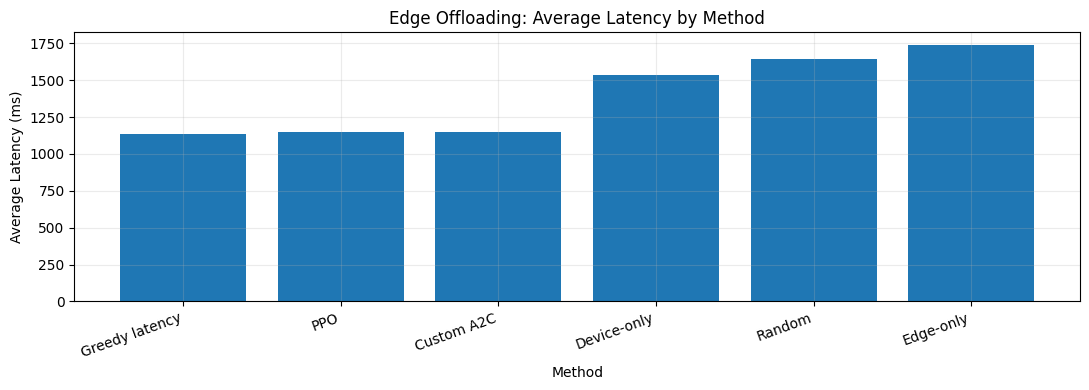

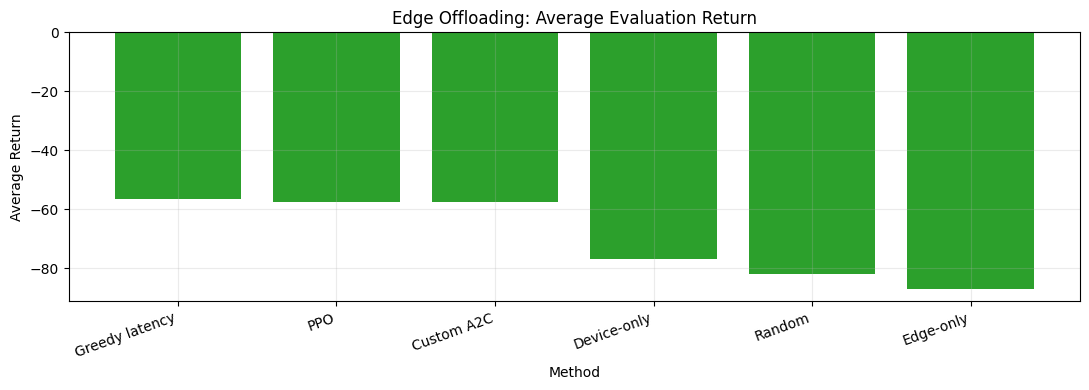

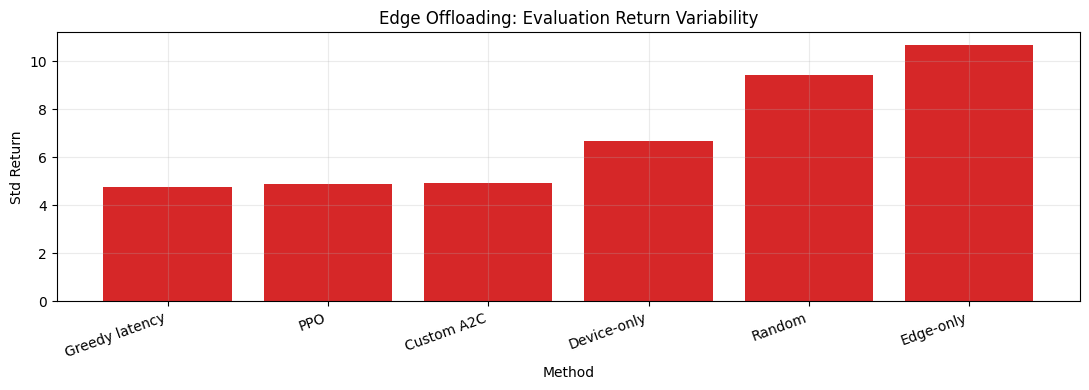

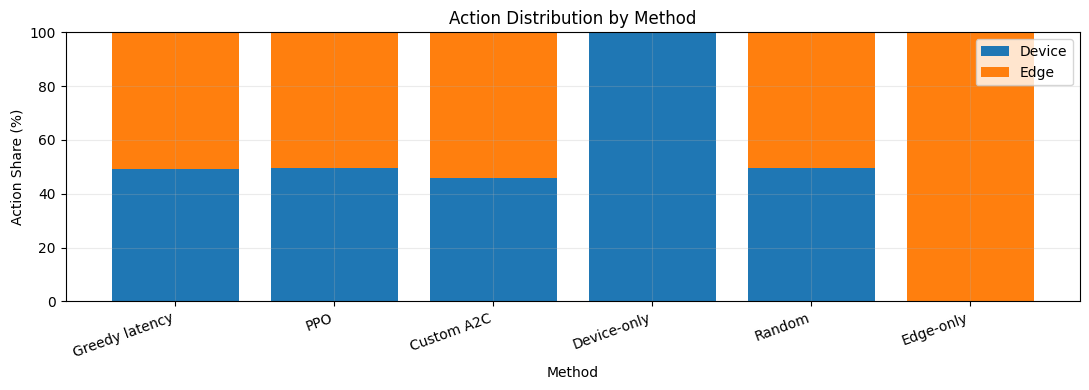

,Method,Episodes,Avg Return,Std Return,Max Return,Final Window Avg,Final Window Std
0,A2C,400,-64.474510,9.098174,-44.530510,-58.168549,4.664693
1,PPO,400,-62.348358,8.923788,-44.468231,-57.983612,4.595471


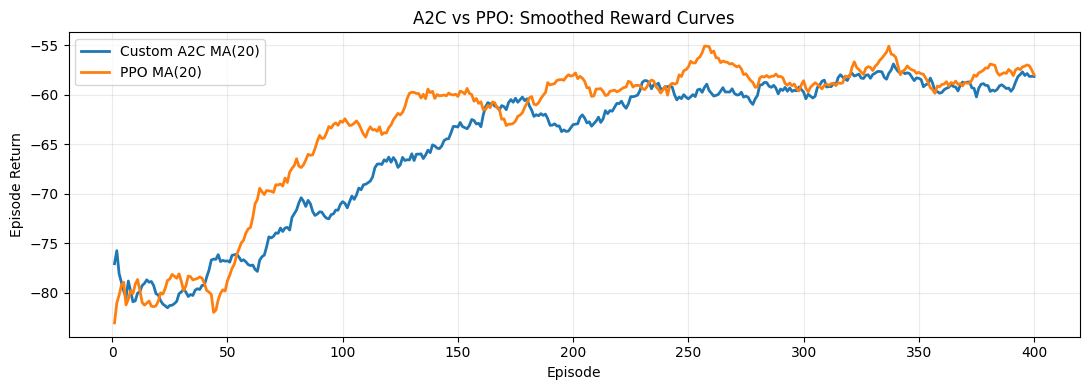

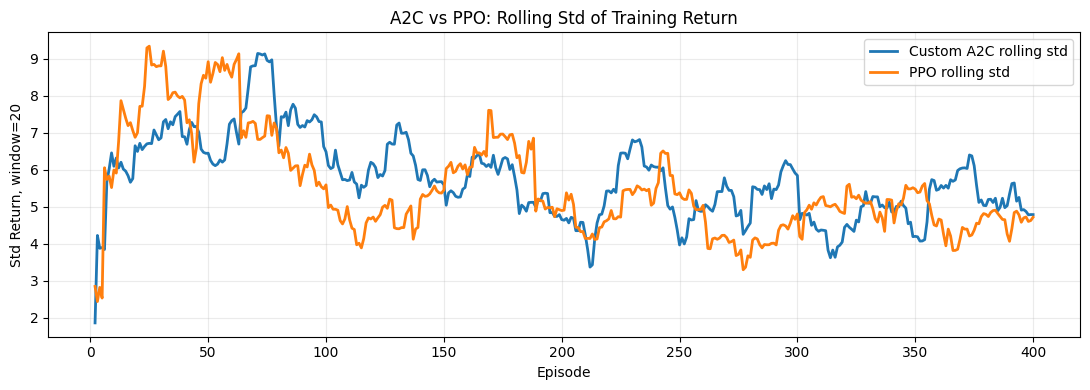

Most stable final window: PPO (std=4.595).
Best final-window average return: PPO (avg=-57.984).


In [9]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []


def add_result(method_name, result):
    """Add one evaluated policy to the comparison table."""
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency (ms)': result['avg_latency'],
        'P95 Latency (ms)': result['p95_latency'],
        'Avg Return': result['avg_return'],
        'Std Return': result['std_return'],
        'Max Return': result['max_return'],
        'Min Return': result['min_return'],
        'Gap to Greedy Latency': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    })


for method_name, result in baseline_results.items():
    add_result(method_name, result)

if 'a2c_available' in globals() and a2c_available and a2c_result is not None:
    add_result('Custom A2C', a2c_result)

if 'ppo_available' in globals() and ppo_available and ppo_result is not None:
    add_result('PPO', ppo_result)

if 'sb3_a2c_available' in globals() and sb3_a2c_available and sb3_a2c_result is not None:
    add_result('SB3 A2C', sb3_a2c_result)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('Avg Latency (ms)').reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(11, 4))
plt.bar(comparison_df['Method'], comparison_df['Avg Latency (ms)'])
plt.title('Edge Offloading: Average Latency by Method')
plt.xlabel('Method')
plt.ylabel('Average Latency (ms)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(comparison_df['Method'], comparison_df['Avg Return'], color='tab:green')
plt.title('Edge Offloading: Average Evaluation Return')
plt.xlabel('Method')
plt.ylabel('Average Return')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.bar(comparison_df['Method'], comparison_df['Std Return'], color='tab:red')
plt.title('Edge Offloading: Evaluation Return Variability')
plt.xlabel('Method')
plt.ylabel('Std Return')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

x = np.arange(len(comparison_df))
plt.figure(figsize=(11, 4))
plt.bar(x, comparison_df['Device %'], label='Device')
plt.bar(x, comparison_df['Edge %'], bottom=comparison_df['Device %'], label='Edge')
plt.xticks(x, comparison_df['Method'], rotation=20, ha='right')
plt.ylim(0, 100)
plt.title('Action Distribution by Method')
plt.xlabel('Method')
plt.ylabel('Action Share (%)')
plt.legend()
plt.tight_layout()
plt.show()

stability_rows = []
if 'a2c_training_summary' in globals():
    stability_rows.append(a2c_training_summary)
if 'ppo_training_summary' in globals():
    stability_rows.append(ppo_training_summary)

training_stability_df = pd.DataFrame(stability_rows)
display(training_stability_df)

training_curves = {}
if 'custom_a2c_train_rewards' in globals():
    training_curves['Custom A2C'] = custom_a2c_train_rewards
if 'ppo_train_rewards' in globals():
    training_curves['PPO'] = ppo_train_rewards

plt.figure(figsize=(11, 4))
for method_name, rewards in training_curves.items():
    x_curve = np.arange(1, len(rewards) + 1)
    plt.plot(x_curve, moving_average(rewards, 20), lw=2, label=f'{method_name} MA(20)')
plt.title('A2C vs PPO: Smoothed Reward Curves')
plt.xlabel('Episode')
plt.ylabel('Episode Return')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
for method_name, rewards in training_curves.items():
    rolling_std = pd.Series(rewards).rolling(window=20, min_periods=2).std().to_numpy()
    x_curve = np.arange(1, len(rewards) + 1)
    plt.plot(x_curve, rolling_std, lw=2, label=f'{method_name} rolling std')
plt.title('A2C vs PPO: Rolling Std of Training Return')
plt.xlabel('Episode')
plt.ylabel('Std Return, window=20')
plt.legend()
plt.tight_layout()
plt.show()

if len(training_stability_df) >= 2:
    stable_method = training_stability_df.sort_values('Final Window Std').iloc[0]
    best_method = training_stability_df.sort_values('Final Window Avg', ascending=False).iloc[0]
    print(
        f"Most stable final window: {stable_method['Method']} "
        f"(std={stable_method['Final Window Std']:.3f})."
    )
    print(
        f"Best final-window average return: {best_method['Method']} "
        f"(avg={best_method['Final Window Avg']:.3f})."
    )

## CONGRATULATIONS TEAM!

Congratulations on Completing **Lab 05.2 – Continuous and Policy-Based RL with DDPG and PPO**!

**Key Conclusions:**

- You successfully designed and validated an **EdgeOffloadingEnv** that models realistic latency-aware offloading decisions.
- Baseline policies (random, device-only, edge-only, greedy) provided strong reference points for RL performance.
- **Actor-Critic/A2C-style methods** improved learning stability versus pure policy-gradient updates.
- **PPO** demonstrated robust and sample-efficient policy improvement through clipped objective optimization.
- Across experiments, learned policies captured the core trade-off between **local execution cost** and **edge transmission/queue delay**.

**Why This Lab Is Important:**

- It connects RL theory to a practical networking scenario: adaptive edge offloading.
- It shows how policy-based methods can outperform static heuristics in dynamic environments.
- It builds a strong foundation for deploying more advanced RL approaches in real-world edge/cloud systems.

### References

- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- PyTorch documentation: https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026